# Education and Unemployment in San Francisco County, 2010–2024

**Research question:** From 2010 to 2024, how does the rise in the share of adults with a bachelor's degree or higher in San Francisco County track with the county's unemployment rate?

**Hypothesis:** As the bachelor's share rises, unemployment falls, so the two series should have a **negative** relationship.

**Data (FRED):**
- `CASANF0URN`: Unemployment Rate in San Francisco County/City, CA (monthly, not seasonally adjusted)
- `HC01ESTVC1706075`: Bachelor's Degree or Higher, 5-year estimate, San Francisco County/City, CA (annual)

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from dotenv import load_dotenv
from fredapi import Fred
from scipy import stats

load_dotenv()

START_YEAR, END_YEAR = 2010, 2024
ACS_WINDOW_YEARS = 5
COVID_YEARS = [2020, 2021]
RAW_DIR = Path("data/raw")
UNEMPLOYMENT_ID = "CASANF0URN"
BACHELORS_ID = "HC01ESTVC1706075"

## 1. Data retrieval

The FRED API key is read from the `FRED_API_KEY` environment variable (or a git-ignored `.env` file). Each pull is saved to `data/raw/` together with its FRED metadata, so the notebook reruns from the saved CSVs without calling the API.

In [2]:
def load_fred_series(series_id):
    """Return a FRED series and its metadata, downloading them to RAW_DIR on first use."""
    values_path = RAW_DIR / f"{series_id}.csv"
    metadata_path = RAW_DIR / f"{series_id}_metadata.csv"
    if not (values_path.exists() and metadata_path.exists()):
        fred = Fred(api_key=os.environ["FRED_API_KEY"])
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        fred.get_series(series_id).rename_axis("date").rename("value").to_csv(values_path)
        fred.get_series_info(series_id).rename("value").to_csv(metadata_path, index_label="field")
    values = pd.read_csv(values_path, index_col="date", parse_dates=True)["value"]
    metadata = pd.read_csv(metadata_path, index_col="field")["value"]
    return values, metadata


unemployment_monthly, unemployment_metadata = load_fred_series(UNEMPLOYMENT_ID)
bachelors_raw, bachelors_metadata = load_fred_series(BACHELORS_ID)

pd.DataFrame({
    UNEMPLOYMENT_ID: unemployment_metadata,
    BACHELORS_ID: bachelors_metadata,
}).loc[["title", "units", "frequency", "seasonal_adjustment", "last_updated"]]

,CASANF0URN,HC01ESTVC1706075
field,,
title,Unemployment Rate in San Francisco County/City...,Bachelor's Degree or Higher (5-year estimate) ...
units,Percent,Percent
frequency,Monthly,Annual
seasonal_adjustment,Not Seasonally Adjusted,Not Seasonally Adjusted
last_updated,2026-09-30 14:16:21-05,2026-01-29 09:36:48-06


## 2. Cleaning

### Date ranges

Each ACS 5-year estimate is labeled by the last year of its window (2010 = the 2006–2010 average). The cell below lists which end years FRED has published in the study period.

In [3]:
bachelors = bachelors_raw.loc[str(START_YEAR):str(END_YEAR)]
bachelors.index = bachelors.index.year

expected_years = range(START_YEAR, END_YEAR + 1)
missing_acs_years = sorted(set(expected_years) - set(bachelors.dropna().index))
print(f"ACS end years available: {bachelors.dropna().index.min()}–{bachelors.dropna().index.max()}")
print(f"ACS years missing: {missing_acs_years or 'none'}")

ACS end years available: 2010–2024
ACS years missing: none


### Frequency alignment

Monthly unemployment becomes annual by taking the calendar-year mean of the months available. Any year with fewer than 12 months is flagged. Unemployment is loaded from 2006 so that the 5-year rolling mean for 2010 covers 2006–2010, the same window as the 2010 ACS estimate.

In [4]:
rolling_start_year = START_YEAR - ACS_WINDOW_YEARS + 1
unemployment_in_range = unemployment_monthly.loc[str(rolling_start_year):str(END_YEAR)]
print(f"Missing monthly unemployment values: {unemployment_in_range.isna().sum()}")

months_by_year = unemployment_in_range.groupby(unemployment_in_range.index.year)
unemployment_annual = pd.DataFrame({
    "unemployment": months_by_year.mean(),
    "months_observed": months_by_year.count(),
})
unemployment_annual["partial_year"] = unemployment_annual["months_observed"] < 12
unemployment_annual["unemployment_5yr"] = (
    unemployment_annual["unemployment"].rolling(ACS_WINDOW_YEARS).mean()
)
unemployment_annual = unemployment_annual.loc[START_YEAR:END_YEAR]

partial_years = unemployment_annual.index[unemployment_annual["partial_year"]].tolist()
print(f"Years with fewer than 12 months of unemployment data: {partial_years or 'none'}")

Missing monthly unemployment values: 0
Years with fewer than 12 months of unemployment data: none


### Merge and missing values

Inner-join on `year`. The ACS series is not interpolated: any year without an ACS value drops out of the merged table.

In [5]:
print("NaNs before merge:")
print(f"  unemployment (annual): {unemployment_annual['unemployment'].isna().sum()}")
print(f"  bachelors:             {bachelors.isna().sum()}")

merged = (
    unemployment_annual
    .join(bachelors.dropna().rename("bachelors"), how="inner")
    .rename_axis("year")
)

dropped_years = sorted(set(expected_years) - set(merged.index))
print(f"\nMerged rows: {len(merged)} of {len(expected_years)} expected")
print(f"Years dropped: {dropped_years or 'none'}")
print("\nNaNs after merge:")
print(merged[["unemployment", "unemployment_5yr", "bachelors"]].isna().sum().to_string())

NaNs before merge:
  unemployment (annual): 0
  bachelors:             0

Merged rows: 15 of 15 expected
Years dropped: none

NaNs after merge:
unemployment        0
unemployment_5yr    0
bachelors           0


### Derived columns

- `*_change`: year-over-year change (first difference), in percentage points
- `*_index`: the series rescaled so that 2010 = 100
- `covid`: 1 for 2020–2021, 0 otherwise

In [6]:
SERIES_COLUMNS = ["unemployment", "unemployment_5yr", "bachelors"]

for column in SERIES_COLUMNS:
    merged[f"{column}_change"] = merged[column].diff()
    merged[f"{column}_index"] = merged[column] / merged.loc[START_YEAR, column] * 100

merged["covid"] = merged.index.isin(COVID_YEARS).astype(int)

### Sanity checks

All rates must fall between 0 and 100 percent. 2020 is a known outlier: the COVID shock pushed unemployment far above its trend.

In [7]:
rates_in_range = merged[SERIES_COLUMNS].apply(lambda rate: rate.between(0, 100)).all()
assert rates_in_range.all(), f"Out-of-range rates: {rates_in_range[~rates_in_range].index.tolist()}"

merged[SERIES_COLUMNS].describe().round(2)

,unemployment,unemployment_5yr,bachelors
count,15.00,15.00,15.00
mean,4.90,5.26,55.87
std,2.23,1.49,3.43
min,2.40,3.09,51.20
25%,3.31,4.23,52.65
50%,3.95,4.80,55.80
75%,6.19,6.54,59.15
max,8.96,7.67,60.30


In [8]:
pd.concat([merged.head(3), merged.tail(3)]).round(2)

,unemployment,months_observed,partial_year,unemployment_5yr,bachelors,unemployment_change,unemployment_index,unemployment_5yr_change,unemployment_5yr_index,bachelors_change,bachelors_index,covid
year,,,,,,,,,,,,
2010,8.96,12,False,6.33,51.2,NaN,100.00,NaN,100.00,NaN,100.00,0
2011,8.04,12,False,7.10,51.4,-0.92,89.77,0.77,112.14,0.2,100.39,0
2012,6.81,12,False,7.62,52.0,-1.23,76.00,0.52,120.36,0.6,101.56,0
2022,2.79,12,False,4.38,59.8,-2.78,31.16,-0.08,69.20,0.3,116.80,0
2023,3.43,12,False,4.55,60.1,0.64,38.33,0.17,71.87,0.3,117.38,0
2024,3.95,12,False,4.86,60.3,0.52,44.09,0.31,76.77,0.2,117.77,0


## 3. Charts

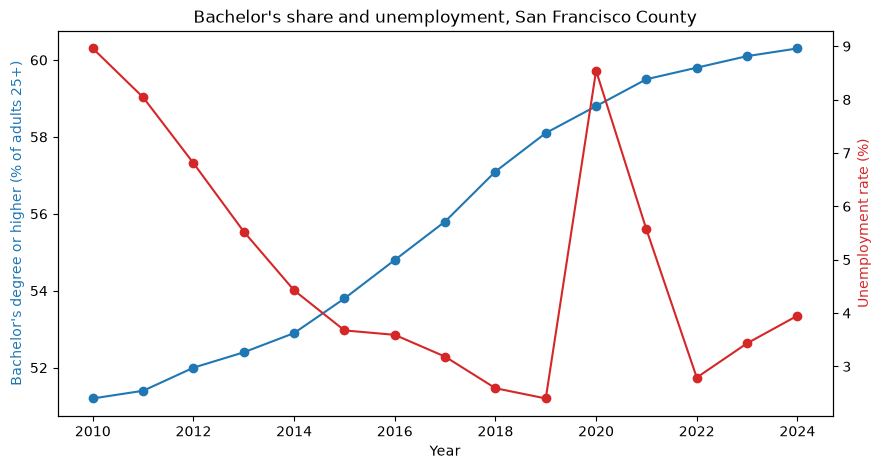

In [9]:
fig, bachelors_axis = plt.subplots(figsize=(10, 5))
unemployment_axis = bachelors_axis.twinx()

bachelors_axis.plot(merged.index, merged["bachelors"], color="tab:blue", marker="o")
unemployment_axis.plot(merged.index, merged["unemployment"], color="tab:red", marker="o")

bachelors_axis.set_ylabel("Bachelor's degree or higher (% of adults 25+)", color="tab:blue")
unemployment_axis.set_ylabel("Unemployment rate (%)", color="tab:red")
bachelors_axis.set_xlabel("Year")
bachelors_axis.set_title("Bachelor's share and unemployment, San Francisco County")
plt.show()

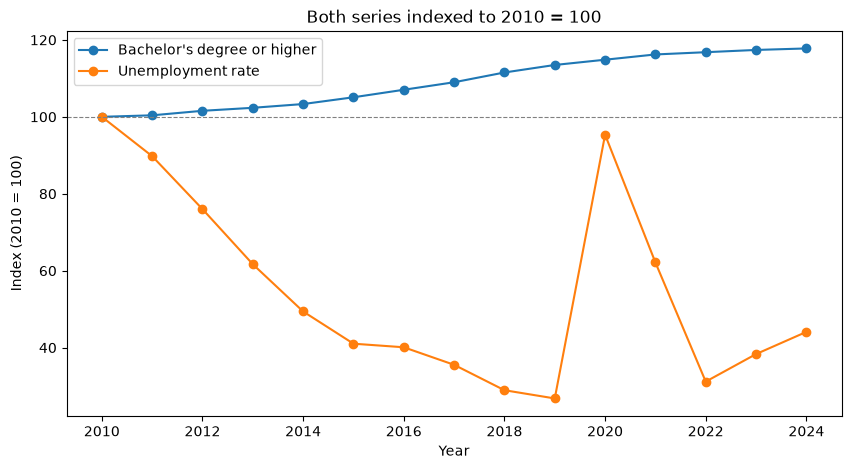

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(merged.index, merged["bachelors_index"], marker="o", label="Bachelor's degree or higher")
ax.plot(merged.index, merged["unemployment_index"], marker="o", label="Unemployment rate")
ax.axhline(100, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel(f"Index ({START_YEAR} = 100)")
ax.set_title(f"Both series indexed to {START_YEAR} = 100")
ax.legend()
plt.show()

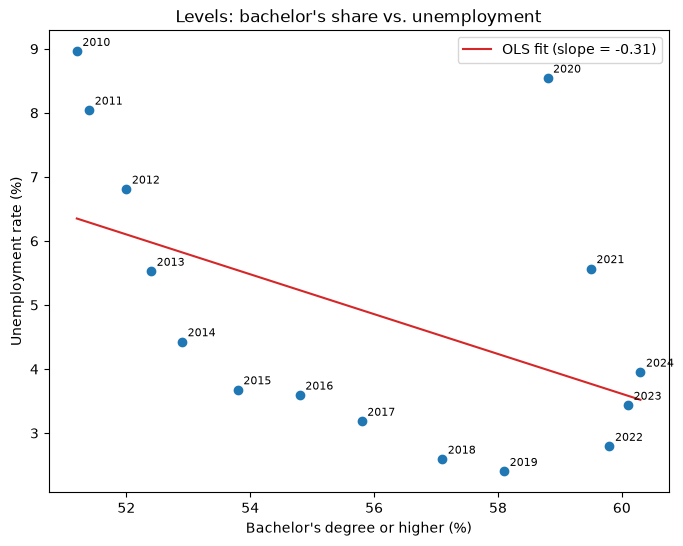

In [11]:
def plot_labeled_scatter(data, x_column, y_column, x_label, y_label, title):
    """Scatter y against x with an OLS fit line and each point labeled by year."""
    points = data[[x_column, y_column]].dropna()
    slope, intercept = np.polyfit(points[x_column], points[y_column], deg=1)
    fit_x = np.linspace(points[x_column].min(), points[x_column].max(), 100)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(points[x_column], points[y_column])
    ax.plot(fit_x, intercept + slope * fit_x, color="tab:red", label=f"OLS fit (slope = {slope:.2f})")
    for year, (x_value, y_value) in points.iterrows():
        ax.annotate(year, (x_value, y_value), textcoords="offset points", xytext=(4, 4), fontsize=8)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    plt.show()


plot_labeled_scatter(
    merged, "bachelors", "unemployment",
    "Bachelor's degree or higher (%)", "Unemployment rate (%)",
    "Levels: bachelor's share vs. unemployment",
)

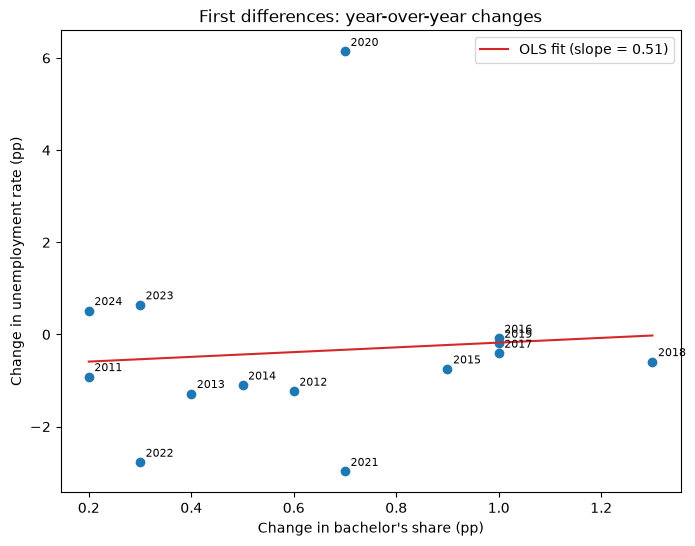

In [12]:
plot_labeled_scatter(
    merged, "bachelors_change", "unemployment_change",
    "Change in bachelor's share (pp)", "Change in unemployment rate (pp)",
    "First differences: year-over-year changes",
)

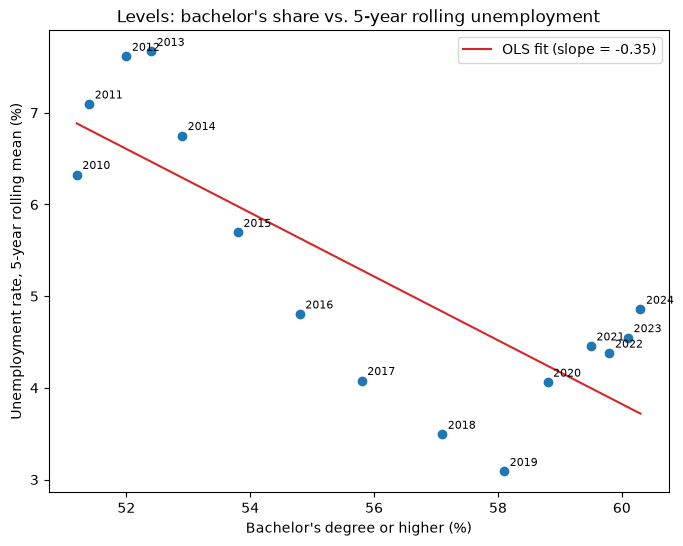

In [13]:
plot_labeled_scatter(
    merged, "bachelors", "unemployment_5yr",
    "Bachelor's degree or higher (%)", "Unemployment rate, 5-year rolling mean (%)",
    "Levels: bachelor's share vs. 5-year rolling unemployment",
)

## 4. Statistical tests

For each sample and unemployment measure, the function below reports:
- Pearson and Spearman correlations on levels
- Pearson correlation on first differences
- OLS `unemployment ~ bachelors + covid` (the `covid` term is left out when the sample excludes 2020–2021, since it would be all zeros)

In the sample without 2020–2021, the 2022 first difference is still measured against 2021, so it carries some of the COVID recovery.

In [14]:
def run_tests(data, outcome):
    """Return correlation and OLS results for `outcome` against the bachelor's share."""
    pearson = stats.pearsonr(data["bachelors"], data[outcome])
    spearman = stats.spearmanr(data["bachelors"], data[outcome])
    changes = data[["bachelors_change", f"{outcome}_change"]].dropna()
    change_pearson = stats.pearsonr(changes["bachelors_change"], changes[f"{outcome}_change"])

    formula = f"{outcome} ~ bachelors" + (" + covid" if data["covid"].any() else "")
    model = smf.ols(formula, data=data).fit()

    return {
        "n": len(data),
        "pearson_r": pearson.statistic,
        "pearson_p": pearson.pvalue,
        "spearman_rho": spearman.statistic,
        "spearman_p": spearman.pvalue,
        "diff_r": change_pearson.statistic,
        "diff_p": change_pearson.pvalue,
        "ols_coef": model.params["bachelors"],
        "ols_se": model.bse["bachelors"],
        "ols_p": model.pvalues["bachelors"],
        "ols_r2": model.rsquared,
    }


samples = {
    "Full sample": merged,
    "Excluding 2020–2021": merged[merged["covid"] == 0],
}
outcomes = {
    "Annual unemployment": "unemployment",
    "5-year rolling unemployment": "unemployment_5yr",
}

results = pd.DataFrame({
    (sample_name, outcome_name): run_tests(sample, outcome)
    for sample_name, sample in samples.items()
    for outcome_name, outcome in outcomes.items()
}).T
results.round(3)

n  pearson_r  pearson_p  \
Full sample         Annual unemployment          15.0     -0.478      0.071   
                    5-year rolling unemployment  15.0     -0.798      0.000   
Excluding 2020–2021 Annual unemployment          13.0     -0.763      0.002   
                    5-year rolling unemployment  13.0     -0.784      0.002   

                                                 spearman_rho  spearman_p  \
Full sample         Annual unemployment                -0.496       0.060   
                    5-year rolling unemployment        -0.650       0.009   
Excluding 2020–2021 Annual unemployment                -0.775       0.002   
                    5-year rolling unemployment        -0.720       0.006   

                                                 diff_r  diff_p  ols_coef  \
Full sample         Annual unemployment           0.084   0.774    -0.484   
                    5-year rolling unemployment  -0.563   0.036    -0.355   
Excluding 2020–2021 Annual unemployment           0.156   0.628    -0.477   
                    5-year rolling unemployment  -0.703   0.011    -0.357   

                                                 ols_se  ols_p  ols_r2  
Full sample         Annual unemployment           0.125  0.002   0.623  
                    5-year rolling unemployment   0.082  0.001   0.638  
Excluding 2020–2021 Annual unemployment           0.122  0.002   0.582  
                    5-year rolling unemployment   0.085  0.002   0.615

Full OLS output for the main specification:

In [15]:
smf.ols("unemployment ~ bachelors + covid", data=merged).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           unemployment   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     9.927
Date:                Wed, 30 Sep 2026   Prob (F-statistic):            0.00286
Time:                        20:18:53   Log-Likelihood:                -25.466
No. Observations:                  15   AIC:                             56.93
Df Residuals:                      12   BIC:                             59.06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     31.3497      6.940      4.517      0.001      16.228      46.471
bachelors     -0.4838      0.125     -3.866      0.002      -0.756      -0.211
covid          4.3196      1.218      3.546      0.004       1.665       6.974
==============================================================================
Omnibus:                        4.311   Durbin-Watson:                   0.737
Prob(Omnibus):                  0.116   Jarque-Bera (JB):                1.546
Skew:                           0.349   Prob(JB):                        0.462
Kurtosis:                       1.590   Cond. No.                     1.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Caveats

- **Small sample.** There are only about 15 annual observations, so tests have little power and single years (such as 2020) carry a lot of weight.
- **Overlapping ACS windows.** Each 5-year estimate shares four years with its neighbor, so the education series is very smooth and autocorrelated. That understates the true uncertainty in the levels tests.
- **Spurious correlation.** Two series that both trend over time will correlate whether or not one affects the other. The first-difference test is the check on this.
- **Ecological fallacy.** A county-level correlation says nothing about whether any individual's degree lowers their own chance of unemployment.

## 5. Conclusion

Between 2010 and 2024 the share of San Francisco County adults with a bachelor's degree or higher rose steadily, from 51.2% to 60.3%. Over the same years unemployment fell from about 9.0% to 4.0%, apart from the COVID spike in 2020. In levels the relationship is negative, as expected. On the full sample Pearson r = −0.48 (p = 0.07), and without 2020–2021 it strengthens to r = −0.76 (p = 0.002). After controlling for COVID, the OLS coefficient on bachelor's share is −0.48 (SE 0.13, p = 0.002, R² = 0.62).

The year-to-year relationship does not hold up, though. The first-difference correlation with annual unemployment is r = 0.08 (p = 0.77) on the full sample and 0.16 (p = 0.63) without 2020–2021. By the criteria in the plan, this **contradicts** the hypothesis: the negative levels correlation mostly reflects two series trending in opposite directions through the post-2010 recovery, not education and unemployment moving together. The first-difference correlation with 5-year rolling unemployment is negative (r = −0.56, p = 0.04), but that is weak evidence because both series are overlapping 5-year averages. With n = 15, none of these results is firm.